In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [5]:
import pandas as pd

df_raw = pd.read_csv("../data/processed/dataset_combined.csv", sep=";")

print("Nomes originais das marcas neste ficheiro do Kaggle:")
print(df_raw['Label'].value_counts())

Nomes originais das marcas neste ficheiro do Kaggle:
Label
Anthropic    2000
Google       2000
Human        2000
Meta         2000
OpenAI       2000
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing import clean_dataframe

sns.set_theme(style="whitegrid")

Total de textos -> Exemplos: 125 | Kaggle DAIGT: 10000


,ID,Text,Label
0,D1-1,"It is an approximation useful in chemistry, bu...",Human
1,D1-2,"PET scanning, or Positron Emission Tomography,...",Meta


,ID,Text,Label
0,COMBINED-1,"Dear Principal Smith, I am writing to express ...",Anthropic
1,COMBINED-2,The use of facial recognition technology like ...,Anthropic


/tmp/ipykernel_38070/2269074902.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='viridis', ax=axes[0])
/tmp/ipykernel_38070/2269074902.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x='Label', palette='viridis', ax=axes[1])


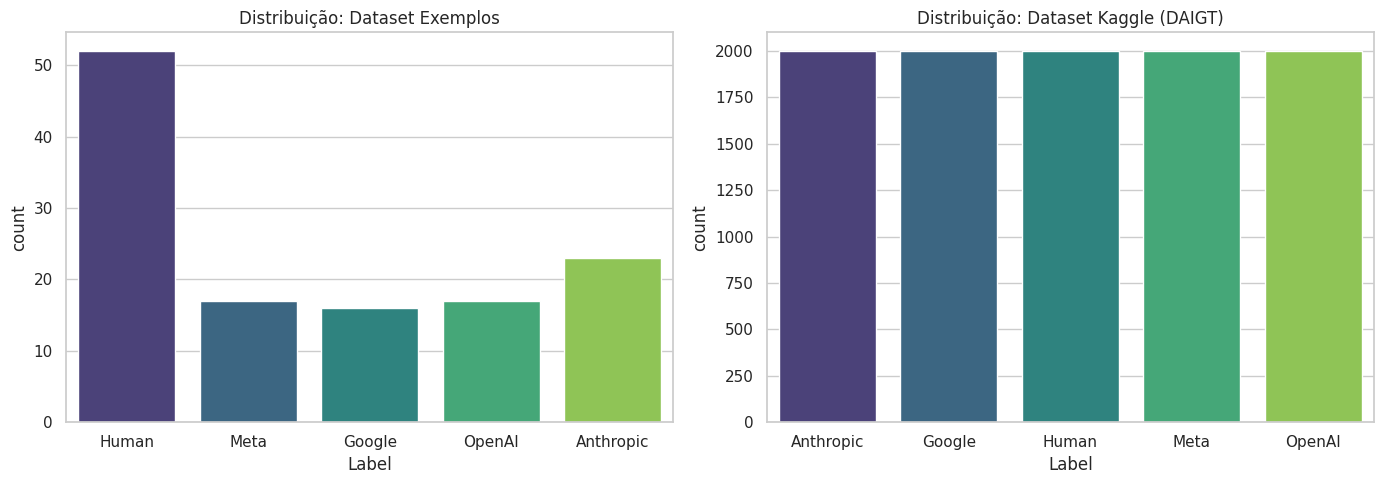

--- Contagem Exemplos ---
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64

--- Contagem Kaggle ---
Label
Anthropic    2000
Google       2000
Human        2000
Meta         2000
OpenAI       2000
Name: count, dtype: int64


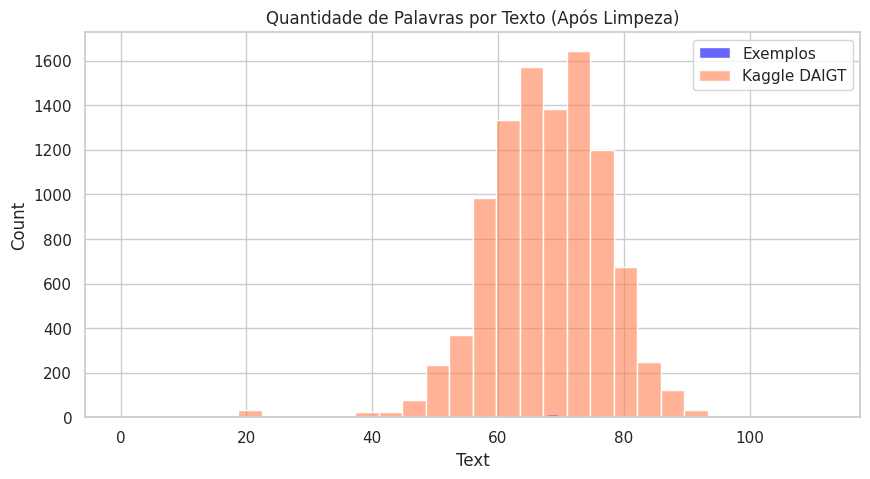


Tamanho médio -> Exemplos: 67 palavras | Kaggle: 68 palavras


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.data_processing import clean_dataframe

df = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";")
df1 = pd.read_csv("../data/processed/dataset_combined.csv", sep=";")

print(f"Total de textos -> Exemplos: {len(df)} | Kaggle DAIGT: {len(df1)}")
display(df.head(2))
display(df1.head(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Label', palette='viridis', ax=axes[0])
axes[0].set_title("Distribuição: Dataset Exemplos")

sns.countplot(data=df1, x='Label', palette='viridis', ax=axes[1])
axes[1].set_title("Distribuição: Dataset Kaggle (DAIGT)")

plt.tight_layout()
plt.show()

print("--- Contagem Exemplos ---")
print(df['Label'].value_counts())
print("\n--- Contagem Kaggle ---")
print(df1['Label'].value_counts())

df_clean = clean_dataframe(df, text_column='Text')
df1_clean = clean_dataframe(df1, text_column='Text')

tamanhos = df_clean['Text'].apply(lambda x: len(str(x).split()))
tamanhos1 = df1_clean['Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(tamanhos, bins=30, color='blue', alpha=0.6, label='Exemplos')
sns.histplot(tamanhos1, bins=30, color='coral', alpha=0.6, label='Kaggle DAIGT')
plt.title("Quantidade de Palavras por Texto (Após Limpeza)")
plt.legend()
plt.show()

print(f"\nTamanho médio -> Exemplos: {tamanhos.mean():.0f} palavras | Kaggle: {tamanhos1.mean():.0f} palavras")